In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pprint
import pandas as pd

from hedpy.parameters.compute import data_index as exp_data_index
from hedpy.parameters.compute.data_index import ComputeData
from hedpy.experiment.xrays import load_pds, window_average_frames, split_into_frames
from hedpy.utils import fiuza_mfp, get_closest


plt.style.use("ggplot")

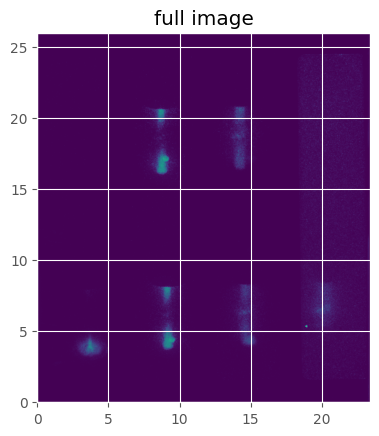

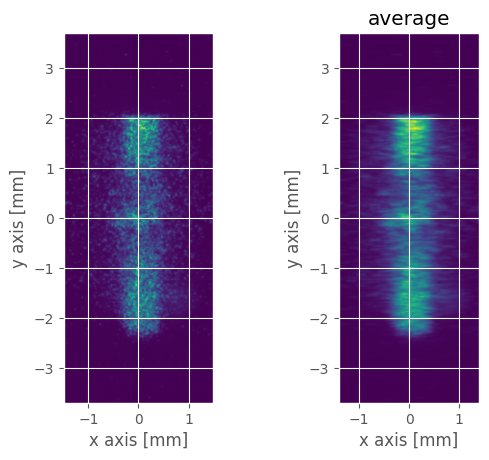

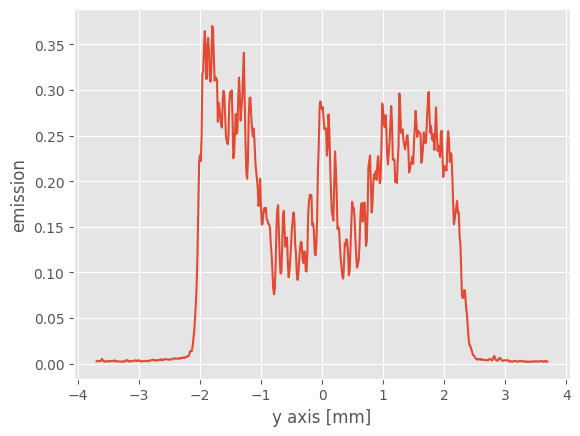

In [10]:
shot = 98596
out = load_pds(shot, path_to_xrfc="../../data_analysis/XRFC/")

plt.imshow(out[2], extent=[np.min(out[0]), np.max(out[0]), np.min(out[1]), np.max(out[1])])
plt.title("full image")

split = split_into_frames(
    *out, 
    y_center=7.3, 
    x_centers=np.array([3.5, 9.1, 14.2, 20]),
    target_thickness=0.5,
)
x = split[0]
y = split[1]
frame = split[2][-2]
fig, axs = plt.subplots(1, 2)
axs[0].imshow(split[2][-2], extent=[np.min(x), np.max(x), np.min(y), np.max(y)])
axs[0].set_xlabel("x axis [mm]")
axs[0].set_ylabel("y axis [mm]")

x_avg, y_avg, frames = window_average_frames(*split, xaxis_window=15, yaxis_window=1)
# print(np.shape(frames[2][-2]))
axs[1].imshow(frames[-2], extent=[np.min(x_avg), np.max(x_avg), np.min(y_avg), np.max(y_avg)])
axs[1].set_xlabel("x axis [mm]")
axs[1].set_ylabel("y axis [mm]")
axs[1].set_title("average")

fig, ax = plt.subplots()
x_ind = get_closest(x_avg, 0)
ax.plot(y_avg, frames[-2][:, x_ind])
ax.set_ylabel("emission")
ax.set_xlabel("y axis [mm]")

plt.show()